# Bike Sharing Demand Prediction Using Machine Learning

## Introduction

This project uses the Kaggle Bike Sharing Demand dataset to analyse factors affecting bike rentals and build machine learning models to predict the total number of bikes rented.

The dataset contains hourly bike rental information along with factors such as season, weather, temperature, humidity, and wind speed.

The main target variable for the regression task is **`count`**, which represents the total number of bikes rented during a particular hour.


## 1. Importing Libraries and Loading the Dataset

The first step is to import the required Python libraries and load the Bike Sharing Demand dataset into a Pandas DataFrame.

Pandas is used to work with tabular data. The dataset is stored in the variable `data` after loading the `train.csv` file.


In [2]:
import pandas as pd
data = pd.read_csv('/train.csv')

## 2. Understanding the Dataset

Before building machine learning models, it is important to understand the dataset.

In this section, the following checks are performed:

* Displaying the first five rows.
* Displaying the last five rows.
* Checking the number of rows and columns.
* Checking column names.
* Checking data types.
* Generating summary statistics.
* Checking the number of unique values.
* Examining the overall structure of the dataset.


In [ ]:
data.head ()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [ ]:
data.tail()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129
10885,2012-12-19 23:00:00,4,0,1,1,13.12,16.665,66,8.9981,4,84,88


In [ ]:
data.shape

(10886, 12)

In [ ]:
data.columns

Index(['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp',
       'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count'],
      dtype='object')

In [ ]:
data.dtypes

,0
datetime,object
season,int64
holiday,int64
workingday,int64
weather,int64
temp,float64
atemp,float64
humidity,int64
windspeed,float64
casual,int64


In [ ]:
data.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


In [ ]:
data.nunique()


,0
datetime,10886
season,4
holiday,2
workingday,2
weather,4
temp,49
atemp,60
humidity,89
windspeed,28
casual,309


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


### Initial Observations

* The dataset contains **10,886 rows and 12 columns**.
* Each row represents bike rental information for a particular hour.
* The dataset contains numerical, categorical, and date/time information.
* The target variable for the regression task is **`count`**, which represents the total number of bikes rented.
* The `datetime` column contains date and time information and requires special handling if it is used as a machine learning feature.
* Columns such as `season` and `weather` use numbers to represent categories.


## 3. Data Cleaning

Data cleaning is performed to identify potential problems in the dataset before training machine learning models.

The following checks are performed:

* Missing values.
* Duplicate rows.
* Obvious invalid or inconsistent values.

Cleaning the data helps ensure that machine learning models are trained using reliable information.


In [ ]:
data.isnull().sum()

,0
datetime,0
season,0
holiday,0
workingday,0
weather,0
temp,0
atemp,0
humidity,0
windspeed,0
casual,0


Missing Values Observation: No missing values were found in any column of the dataset. Therefore, no missing-value treatment was required.

In [ ]:
data.duplicated().sum()

np.int64(0)

Duplicate Rows Observation: No duplicate rows were found in the dataset. Therefore, no duplicate rows needed to be removed.

In [3]:
data[['season', 'weather', 'temp', 'humidity', 'windspeed', 'casual', 'registered', 'count']].agg(['min', 'max'])

,season,weather,temp,humidity,windspeed,casual,registered,count
min,1,1,0.82,0,0.0000,0,0,1
max,4,4,41.00,100,56.9969,367,886,977


Invalid Values Observation: Important numerical and categorical columns were checked for obvious invalid values. Season and weather values were within their expected range of 1–4, humidity ranged from 0–100, and rental-related columns contained no negative values. No obvious invalid or inconsistent values were identified.

## 4. Exploratory Data Visualization

Data visualization is used to better understand the distribution of bike rentals and the relationship between different variables.

The following visualizations are created:

1. Distribution of total bike rentals.
2. Relationship between temperature and total bike rentals.
3. Comparison of bike rental counts across different seasons.


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

Loading different graph to check relationship between them

### Distribution of total bike rental
The distribution of total bike rentals is positively skewed, with most observations having lower rental counts and progressively fewer observations having high rental counts.

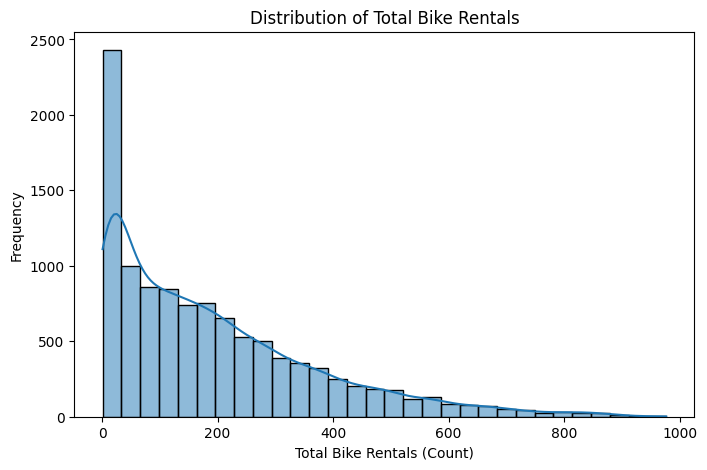

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(data['count'], bins=30, kde=True)
plt.title('Distribution of Total Bike Rentals')
plt.xlabel('Total Bike Rentals (Count)')
plt.ylabel('Frequency')
plt.show()

###Relationship Between Temperature and Bike Rentals
Bike rental counts generally tend to increase as temperature rises from low to moderate temperatures. However, there is considerable variation at the same temperature, showing that temperature alone does not determine bike rental demand.

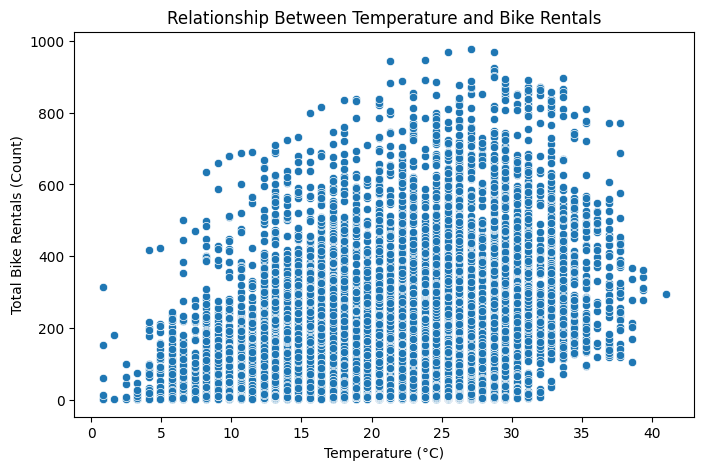

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=data, x='temp', y='count')
plt.title('Relationship Between Temperature and Bike Rentals')
plt.xlabel('Temperature (°C)')
plt.ylabel('Total Bike Rentals (Count)')
plt.show()

### Feature Engineering

First, convert the 'datetime' column to a datetime object and extract time-based features such as hour, day of the week, month, and year. These features can be crucial for understanding temporal patterns in bike rentals.

In [ ]:
data['datetime'] = pd.to_datetime(data['datetime'])
data['hour'] = data['datetime'].dt.hour
data['dayofweek'] = data['datetime'].dt.dayofweek
data['month'] = data['datetime'].dt.month
data['year'] = data['datetime'].dt.year
display(data.head())

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,hour,dayofweek,month,year
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,0,5,1,2011
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1,5,1,2011
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2,5,1,2011
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,3,5,1,2011
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,4,5,1,2011


### Hourly Distribution of Bike Rentals

Let's visualize how the total bike rentals (`count`) are distributed across different hours of the day. This can reveal peak usage times.

/tmp/ipykernel_2053/575948655.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='hour', y='count', data=hourly_rentals, palette='viridis', ax=ax)


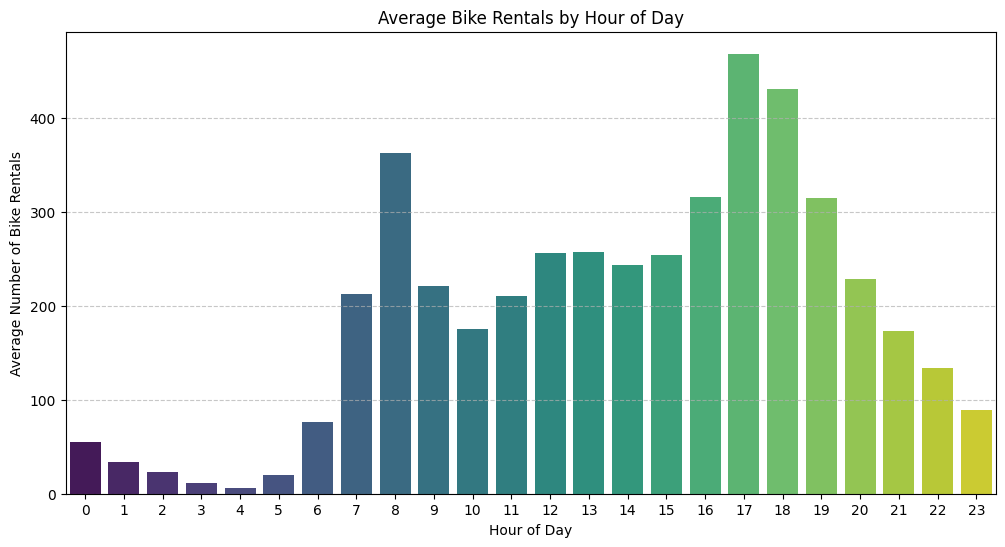

In [ ]:
# Calculate average bike rentals per hour
hourly_rentals = data.groupby('hour')['count'].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x='hour', y='count', data=hourly_rentals, palette='viridis', ax=ax)
ax.set_title('Average Bike Rentals by Hour of Day')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Average Number of Bike Rentals')
plt.xticks(range(0, 24)) # Ensure all hours are shown on x-axis
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Weekly Distribution of Bike Rentals

Next, let's examine the average bike rentals (`count`) across different days of the week. This can reveal daily patterns, such as higher usage on weekdays versus weekends or vice versa.

/tmp/ipykernel_2053/2855487026.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='day_name', y='count', data=daily_rentals, palette='viridis', ax=ax)


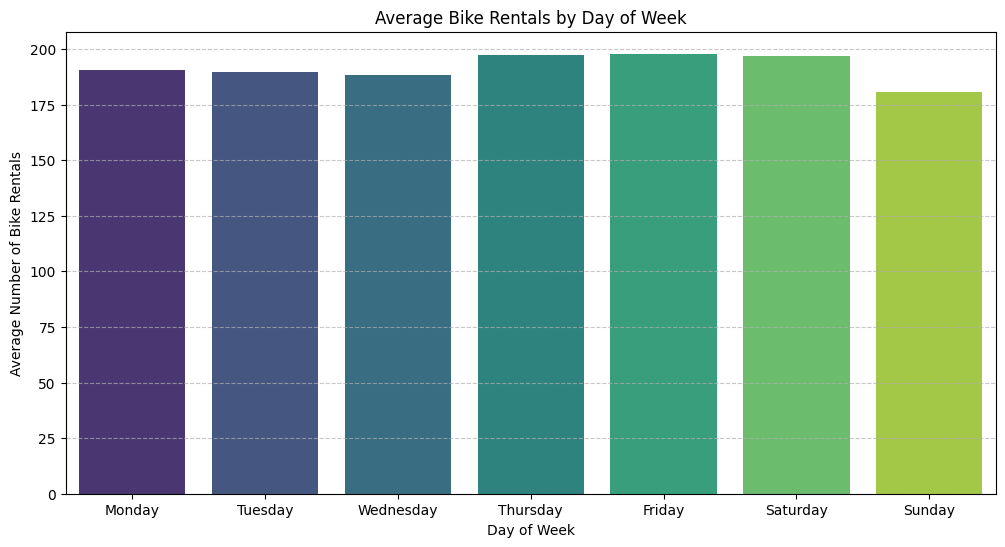

In [ ]:
# Map day of week to names for better readability
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_rentals = data.groupby('dayofweek')['count'].mean().reset_index()
daily_rentals['day_name'] = daily_rentals['dayofweek'].map(lambda x: day_names[x])

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x='day_name', y='count', data=daily_rentals, palette='viridis', ax=ax)
ax.set_title('Average Bike Rentals by Day of Week')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Average Number of Bike Rentals')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Seasonal Distribution of Bike Rentals

Let's visualize the average bike rentals (`count`) across different seasons. This will help us understand seasonal trends and how they impact bike usage.

/tmp/ipykernel_2053/1512800204.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='season_name', y='count', data=seasonal_rentals, palette='winter_r', ax=ax)


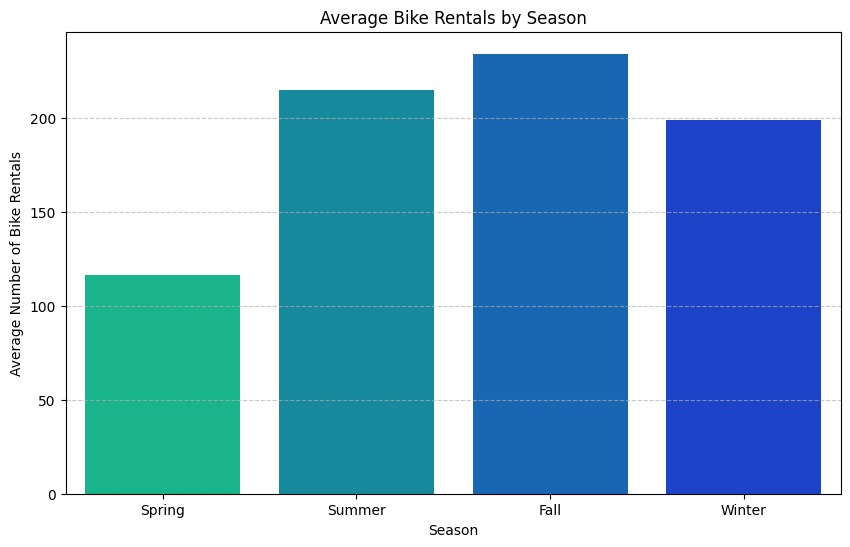

In [ ]:
# Map season to names for better readability
season_names = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
seasonal_rentals = data.groupby('season')['count'].mean().reset_index()
seasonal_rentals['season_name'] = seasonal_rentals['season'].map(season_names)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x='season_name', y='count', data=seasonal_rentals, palette='winter_r', ax=ax)
ax.set_title('Average Bike Rentals by Season')
ax.set_xlabel('Season')
ax.set_ylabel('Average Number of Bike Rentals')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 5. Feature and Target Selection

For the regression problem, the target variable is `count`, which represents the total number of bikes rented.

The input features are stored in `X`, while the target variable is stored in `y`.

The following columns are excluded from the input features:

* `count` is excluded because it is the value being predicted.
* `datetime` is excluded because it is stored as raw date/time text and was not feature-engineered in this version of the model.
* `casual` and `registered` are excluded because they directly contribute to the total `count`. Using them would cause data leakage because they provide information that is directly related to the answer being predicted.


In [5]:
X = data.drop(['count', 'datetime', 'casual', 'registered'], axis=1)

In [6]:
y = data['count']

In [7]:
X.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed
0,1,0,0,1,9.84,14.395,81,0.0
1,1,0,0,1,9.02,13.635,80,0.0
2,1,0,0,1,9.02,13.635,80,0.0
3,1,0,0,1,9.84,14.395,75,0.0
4,1,0,0,1,9.84,14.395,75,0.0


In [8]:
y.head()

,count
0,16
1,40
2,32
3,13
4,1


## 6. Splitting the Dataset into Training and Testing Data

The dataset is divided into training and testing sets.

* The training data is used to teach the machine learning models.
* The testing data is used to evaluate how well the trained models perform on unseen data.

In this project, 80% of the data is used for training and 20% is used for testing.

A fixed `random_state` is used so that the same data split can be reproduced.


In [9]:
from sklearn.model_selection import train_test_split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (8708, 8)
X_test shape: (2178, 8)
y_train shape: (8708,)
y_test shape: (2178,)


## 7. Linear Regression

Linear Regression is used as the first regression model to predict the total number of bike rentals.

The model is trained using the training data and evaluated using the testing data.

The following regression metrics are used:

* **MAE (Mean Absolute Error):** Measures the average prediction error. Lower values are better.
* **MSE (Mean Squared Error):** Measures prediction errors while giving greater importance to larger errors. Lower values are better.
* **R² Score:** Measures how much variation in the target variable is explained by the model. Higher values are generally better.


In [11]:
from sklearn.linear_model import LinearRegression
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

LinearRegression()

In [12]:
y_pred_linear = linear_model.predict(X_test)

In [ ]:
comparison = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_pred_linear[:10]
})

comparison

,Actual,Predicted
0,127,315.869825
1,13,40.926786
2,163,178.497506
3,233,280.271742
4,222,258.464323
5,166,200.174624
6,144,235.583134
7,376,350.012623
8,601,157.443498
9,53,58.865862


In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [14]:
mae_linear = mean_absolute_error(y_test, y_pred_linear)
print("MAE:", mae_linear)

MAE: 115.04130180057093


In [15]:
mse_linear = mean_squared_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("MSE:", mse_linear)
print("R²:", r2_linear)

MSE: 23906.814693176104
R²: 0.2757033009386365


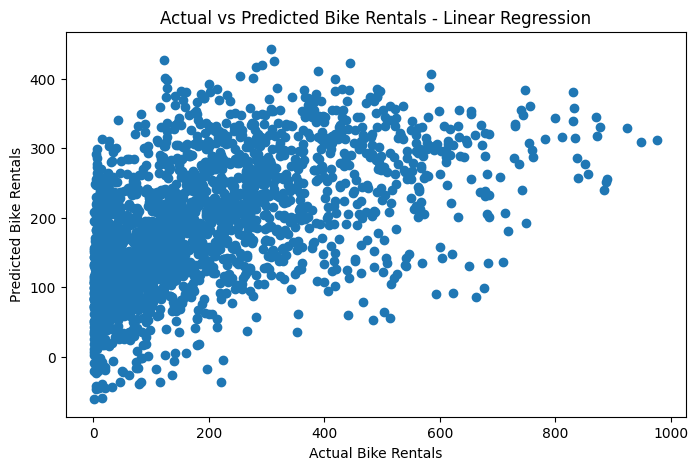

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_linear)
plt.xlabel('Actual Bike Rentals')
plt.ylabel('Predicted Bike Rentals')
plt.title('Actual vs Predicted Bike Rentals - Linear Regression')
plt.show()

### Linear Regression Result

The Linear Regression model achieved an MAE of approximately **115.04**, an MSE of approximately **23,906.81**, and an R² score of approximately **0.276**.

The model captures some relationship between the selected features and bike rental demand, but its overall predictive performance is limited.


## 8. Decision Tree Regressor

A Decision Tree Regressor is trained to predict the total bike rental count.

Unlike Linear Regression, a Decision Tree can model more complex and non-linear relationships between the input features and the target variable.

The model is evaluated using MAE, MSE, and R² score. The first few levels of the tree are also visualized to understand its decision-making structure.


In [27]:
from sklearn.tree import DecisionTreeRegressor

In [17]:
tree_model = DecisionTreeRegressor(random_state=42)

In [18]:
tree_model.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [19]:
y_pred_tree = tree_model.predict(X_test)

In [20]:
mae_tree = mean_absolute_error(y_test, y_pred_tree)
print("Decision Tree MAE:", mae_tree)

Decision Tree MAE: 132.894375573921


In [21]:
mse_tree = mean_squared_error(y_test, y_pred_tree)
r2_tree = r2_score(y_test, y_pred_tree)

print("Decision Tree MSE:", mse_tree)
print("Decision Tree R²:", r2_tree)

Decision Tree MSE: 37475.159505025
Decision Tree R²: -0.13537226412832637


In [22]:
comparison_tree = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_pred_tree[:10]
})

comparison_tree

,Actual,Predicted
0,127,270.0
1,13,2.5
2,163,15.0
3,233,367.0
4,222,9.0
5,166,174.0
6,144,219.0
7,376,414.0
8,601,368.0
9,53,43.0


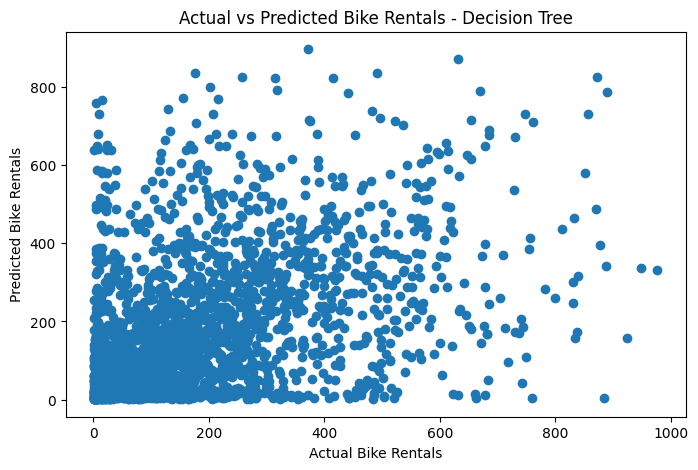

In [24]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_tree)
plt.xlabel('Actual Bike Rentals')
plt.ylabel('Predicted Bike Rentals')
plt.title('Actual vs Predicted Bike Rentals - Decision Tree')
plt.show()

In [23]:
from sklearn.tree import plot_tree

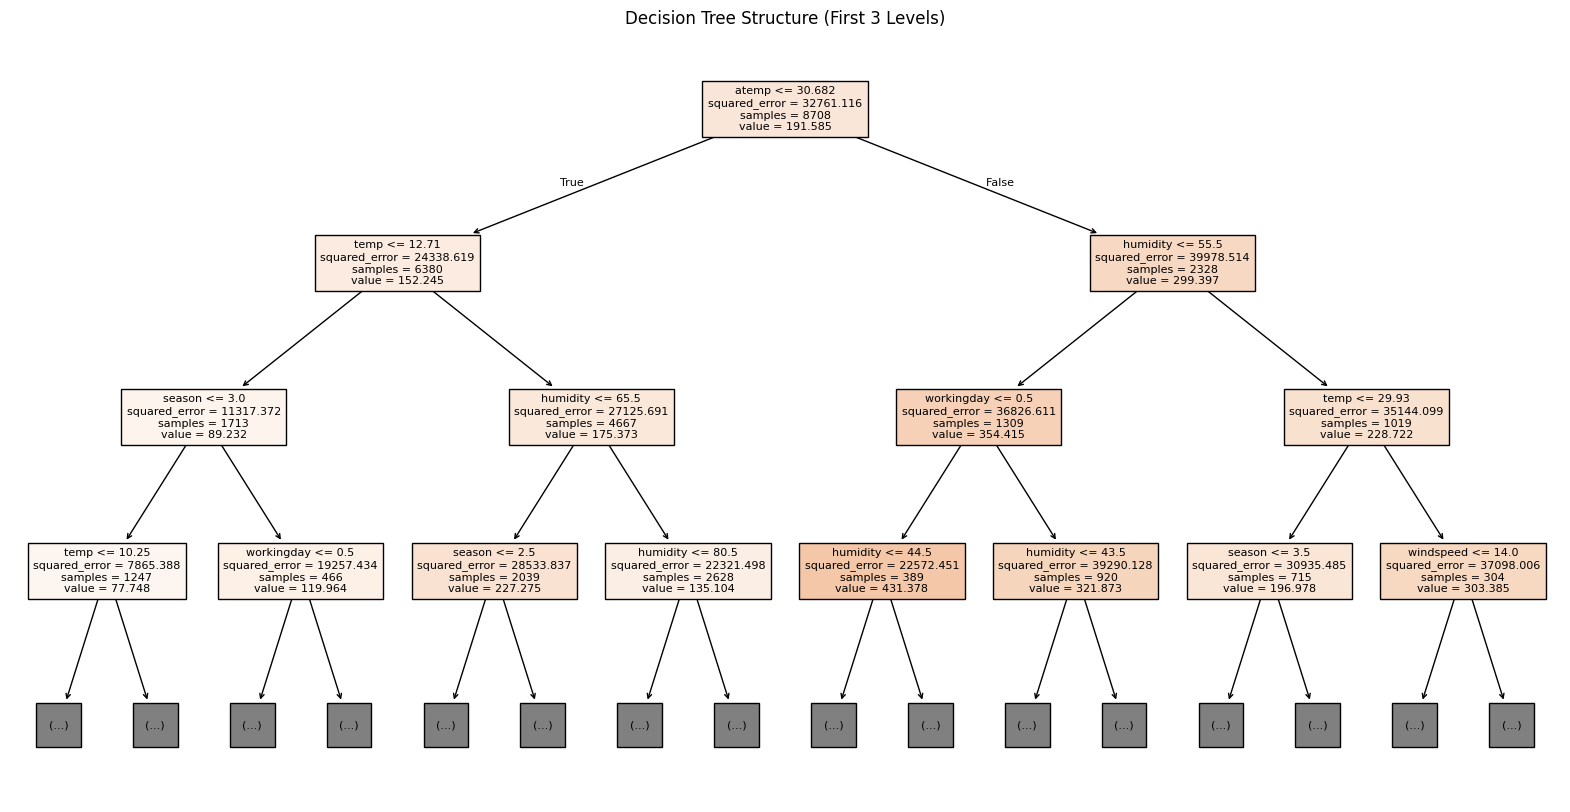

In [25]:
plt.figure(figsize=(20, 10))

plot_tree(
    tree_model,
    feature_names=X.columns,
    filled=True,
    max_depth=3,
    fontsize=8
)

plt.title('Decision Tree Structure (First 3 Levels)')
plt.show()

In [26]:
feature_importance_tree = pd.DataFrame({
    'Feature': X.columns,
    'Importance': tree_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance_tree

,Feature,Importance
6,humidity,0.258047
5,atemp,0.232916
7,windspeed,0.191429
4,temp,0.146331
0,season,0.068096
2,workingday,0.049099
3,weather,0.048083
1,holiday,0.005999


### Decision Tree Result

The Decision Tree Regressor achieved an MAE of approximately **132.89**, an MSE of approximately **37,475.16**, and an R² score of approximately **-0.135**.

The negative R² score indicates poor performance on the testing data. Among the regression models tested so far, the Decision Tree performed worse than Linear Regression.


## 9. Random Forest Regressor

Random Forest is an ensemble machine learning model that combines predictions from multiple Decision Trees.

In this project, the Random Forest model uses 100 Decision Trees. Combining multiple trees can help produce more stable predictions than relying on a single Decision Tree.

The model is evaluated using MAE, MSE, and R² score. Feature importance is also examined to identify which features contributed most to the model's predictions.


In [30]:
from sklearn.ensemble import RandomForestRegressor

In [31]:
forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [32]:
forest_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [33]:
y_pred_forest = forest_model.predict(X_test)

In [34]:
mae_forest = mean_absolute_error(y_test, y_pred_forest)
print("Random Forest MAE:", mae_forest)

Random Forest MAE: 107.53468131646437


In [35]:
mse_forest = mean_squared_error(y_test, y_pred_forest)
r2_forest = r2_score(y_test, y_pred_forest)

print("Random Forest MSE:", mse_forest)
print("Random Forest R²:", r2_forest)

Random Forest MSE: 22922.787480267583
Random Forest R²: 0.30551604141633937


In [36]:
comparison_forest = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_pred_forest[:10]
})

comparison_forest

,Actual,Predicted
0,127,285.729000
1,13,29.423333
2,163,84.698333
3,233,343.296000
4,222,141.475333
5,166,203.584024
6,144,186.872000
7,376,377.712500
8,601,268.534000
9,53,90.307000


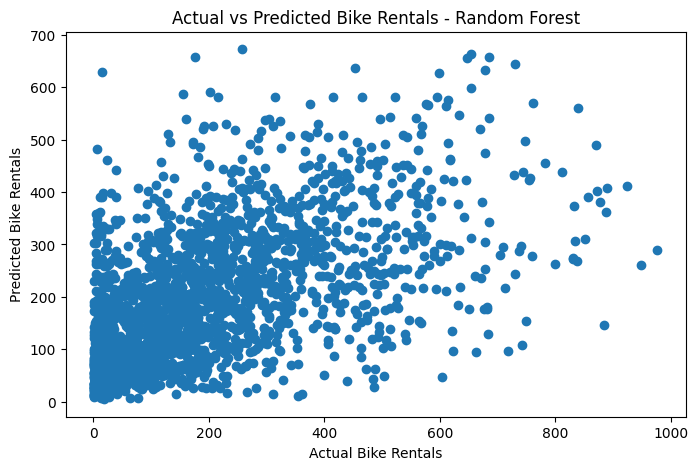

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_forest)
plt.xlabel('Actual Bike Rentals')
plt.ylabel('Predicted Bike Rentals')
plt.title('Actual vs Predicted Bike Rentals - Random Forest')
plt.show()

In [37]:
feature_importance_forest = pd.DataFrame({
    'Feature': X.columns,
    'Importance': forest_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance_forest.head(3)

,Feature,Importance
6,humidity,0.255698
5,atemp,0.234979
7,windspeed,0.196272


### Random Forest Result

The Random Forest Regressor achieved an MAE of approximately **107.53**, an MSE of approximately **22,922.79**, and an R² score of approximately **0.306**.

The three most important features identified by the model were:

1. Humidity
2. Feels-like temperature (`atemp`)
3. Wind speed

The Random Forest model performed better than both Linear Regression and the single Decision Tree based on the regression metrics.


##10. K-Nearest Neighbors (KNN) Regressor

K-Nearest Neighbors predicts a value based on nearby data points.

Because KNN uses distances between observations, feature scaling is important. StandardScaler is used to place the input features on a comparable scale.

Three values of K are tested:

* K = 3
* K = 5
* K = 7

The models are compared using MAE, MSE, and R² score.


In [38]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
scaler = StandardScaler()

In [39]:
X_train_scaled = scaler.fit_transform(X_train)

In [40]:
X_test_scaled = scaler.transform(X_test)

In [41]:
knn_model = KNeighborsRegressor(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

y_pred_knn_5 = knn_model.predict(X_test_scaled)

In [42]:
mae_knn_5 = mean_absolute_error(y_test, y_pred_knn_5)
mse_knn_5 = mean_squared_error(y_test, y_pred_knn_5)
r2_knn_5 = r2_score(y_test, y_pred_knn_5)

print("KNN (K=5) MAE:", mae_knn_5)
print("KNN (K=5) MSE:", mse_knn_5)
print("KNN (K=5) R²:", r2_knn_5)

KNN (K=5) MAE: 108.63085399449035
KNN (K=5) MSE: 23134.36279155188
KNN (K=5) R²: 0.29910601559178496


In [43]:
knn_3 = KNeighborsRegressor(n_neighbors=3)
knn_3.fit(X_train_scaled, y_train)

y_pred_knn_3 = knn_3.predict(X_test_scaled)

mae_knn_3 = mean_absolute_error(y_test, y_pred_knn_3)
mse_knn_3 = mean_squared_error(y_test, y_pred_knn_3)
r2_knn_3 = r2_score(y_test, y_pred_knn_3)

print("KNN (K=3) MAE:", mae_knn_3)
print("KNN (K=3) MSE:", mse_knn_3)
print("KNN (K=3) R²:", r2_knn_3)

KNN (K=3) MAE: 112.23415977961433
KNN (K=3) MSE: 25265.13070094888
KNN (K=3) R²: 0.23455085912074536


In [44]:
knn_7 = KNeighborsRegressor(n_neighbors=7)
knn_7.fit(X_train_scaled, y_train)

y_pred_knn_7 = knn_7.predict(X_test_scaled)

mae_knn_7 = mean_absolute_error(y_test, y_pred_knn_7)
mse_knn_7 = mean_squared_error(y_test, y_pred_knn_7)
r2_knn_7 = r2_score(y_test, y_pred_knn_7)

print("KNN (K=7) MAE:", mae_knn_7)
print("KNN (K=7) MSE:", mse_knn_7)
print("KNN (K=7) R²:", r2_knn_7)

KNN (K=7) MAE: 107.1940836940837
KNN (K=7) MSE: 22059.27273664287
KNN (K=7) R²: 0.33167765627073176


In [45]:
knn_results = pd.DataFrame({
    'K': [3, 5, 7],
    'MAE': [mae_knn_3, mae_knn_5, mae_knn_7],
    'MSE': [mse_knn_3, mse_knn_5, mse_knn_7],
    'R²': [r2_knn_3, r2_knn_5, r2_knn_7]
})

knn_results

,K,MAE,MSE,R²
0,3,112.234160,25265.130701,0.234551
1,5,108.630854,23134.362792,0.299106
2,7,107.194084,22059.272737,0.331678


Conclusion: Best K = 7

Among the three values we tested:

K = 7 has the lowest MAE
K = 7 has the lowest MSE
K = 7 has the highest R²

Therefore, our best KNN model is:

KNN with K = 7

Also, KNN (K=7) is now slightly better than Random Forest based on these results.

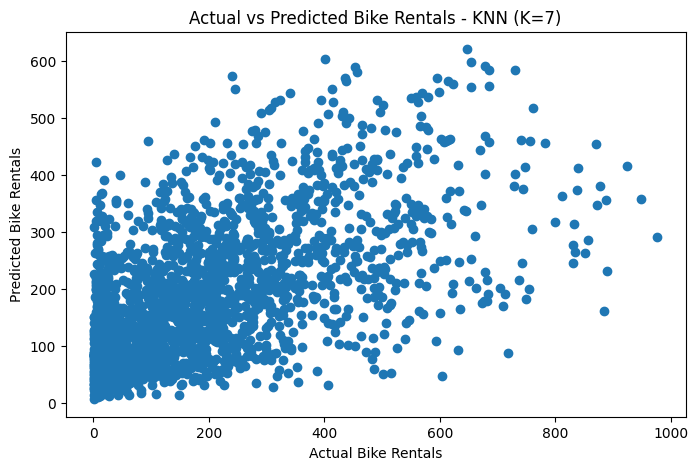

In [46]:
best_knn_model = knn_7
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_knn_7)
plt.xlabel('Actual Bike Rentals')
plt.ylabel('Predicted Bike Rentals')
plt.title('Actual vs Predicted Bike Rentals - KNN (K=7)')
plt.show()

In [47]:
comparison_knn = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_pred_knn_7[:10]
})

comparison_knn

,Actual,Predicted
0,127,293.142857
1,13,37.571429
2,163,118.285714
3,233,275.000000
4,222,161.428571
5,166,203.571429
6,144,169.428571
7,376,409.714286
8,601,157.285714
9,53,46.000000


In [48]:
data['count'].median()
y_class = (data['count'] > data['count'].median()).astype(int)


In [85]:
y_class.value_counts()

,count
count,
0,5452
1,5434


In [50]:
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X, y_class, test_size=0.2, random_state=42
)

In [51]:
print("X_train:", X_train_class.shape)
print("X_test:", X_test_class.shape)
print("y_train:", y_train_class.shape)
print("y_test:", y_test_class.shape)

X_train: (8708, 8)
X_test: (2178, 8)
y_train: (8708,)
y_test: (2178,)


##11. Logistic Regression

In [52]:
scaler_class = StandardScaler()

X_train_class_scaled = scaler_class.fit_transform(X_train_class)
X_test_class_scaled = scaler_class.transform(X_test_class)

In [53]:
from sklearn.linear_model import LogisticRegression

In [54]:
logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train_class_scaled, y_train_class)

LogisticRegression(max_iter=1000)

In [55]:
y_pred_logistic = logistic_model.predict(X_test_class_scaled)

In [56]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

accuracy_logistic = accuracy_score(y_test_class, y_pred_logistic)

print("Logistic Regression Accuracy:", accuracy_logistic)

Logistic Regression Accuracy: 0.72910927456382


In [57]:
cm = confusion_matrix(y_test_class, y_pred_logistic)

cm

array([[806, 287],
       [303, 782]])

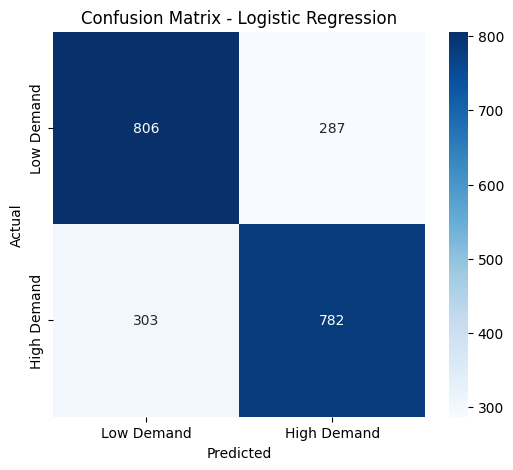

In [58]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Low Demand', 'High Demand'],
    yticklabels=['Low Demand', 'High Demand']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

In [59]:
print(classification_report(y_test_class, y_pred_logistic))

              precision    recall  f1-score   support

           0       0.73      0.74      0.73      1093
           1       0.73      0.72      0.73      1085

    accuracy                           0.73      2178
   macro avg       0.73      0.73      0.73      2178
weighted avg       0.73      0.73      0.73      2178



### Random Forest Result

The Random Forest Regressor achieved an MAE of approximately **107.53**, an MSE of approximately **22,922.79**, and an R² score of approximately **0.306**.

The three most important features identified by the model were:

1. Humidity
2. Feels-like temperature (`atemp`)
3. Wind speed

The Random Forest model performed better than both Linear Regression and the single Decision Tree based on the regression metrics.


###
Logistic Regression cannot be directly compared with the other four models using MAE/MSE/R² because it solves a different problem:

Linear Regression, Decision Tree, Random Forest, and KNN → predict the exact numerical count.
Logistic Regression → predicts Low Demand or High Demand.

So we will create two comparison tables.

In [63]:
regression_results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Decision Tree Regressor',
        'Random Forest Regressor',
        'KNN Regressor (K=7)'
    ],
    'MAE': [
        mae_linear,
        mae_tree,
        mae_forest,
        mae_knn_7
    ],
    'MSE': [
        mse_linear,
        mse_tree,
        mse_forest,
        mse_knn_7
    ],
    'R²': [
        r2_linear,
        r2_tree,
        r2_forest,
        r2_knn_7
    ]
})

regression_results

,Model,MAE,MSE,R²
0,Linear Regression,115.041302,23906.814693,0.275703
1,Decision Tree Regressor,132.894376,37475.159505,-0.135372
2,Random Forest Regressor,107.534681,22922.787480,0.305516
3,KNN Regressor (K=7),107.194084,22059.272737,0.331678


In [64]:
regression_results.sort_values(by='R²', ascending=False)

,Model,MAE,MSE,R²
3,KNN Regressor (K=7),107.194084,22059.272737,0.331678
2,Random Forest Regressor,107.534681,22922.787480,0.305516
0,Linear Regression,115.041302,23906.814693,0.275703
1,Decision Tree Regressor,132.894376,37475.159505,-0.135372


In [60]:
classification_results = pd.DataFrame({
    'Model': ['Logistic Regression'],
    'Task': ['Low Demand vs High Demand Classification'],
    'Accuracy': [accuracy_logistic]
})

classification_results

,Model,Task,Accuracy
0,Logistic Regression,Low Demand vs High Demand Classification,0.729109


In [65]:
best_model = regression_results.loc[regression_results['R²'].idxmax()]

print("Best Regression Model:")
print(best_model)

Best Regression Model:
Model    KNN Regressor (K=7)
MAE               107.194084
MSE             22059.272737
R²                  0.331678
Name: 3, dtype: object


In [66]:
worst_model = regression_results.loc[regression_results['R²'].idxmin()]

print("Worst Regression Model:")
print(worst_model)

Worst Regression Model:
Model    Decision Tree Regressor
MAE                   132.894376
MSE                 37475.159505
R²                     -0.135372
Name: 1, dtype: object


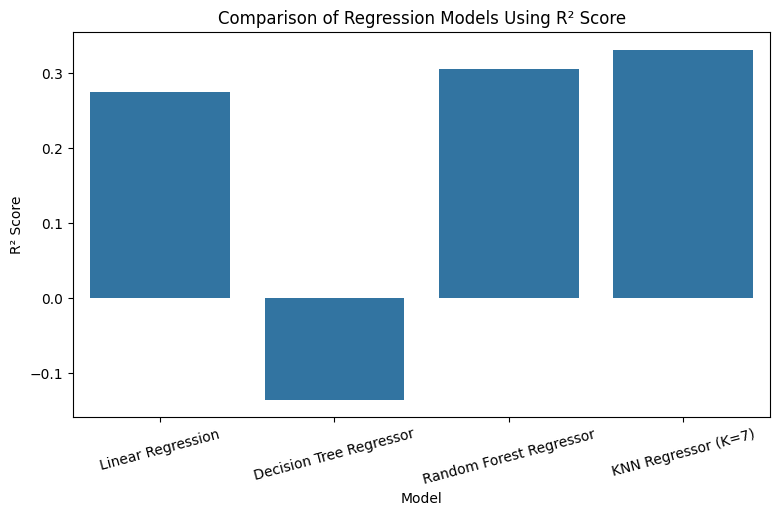

In [67]:
plt.figure(figsize=(9, 5))
sns.barplot(data=regression_results, x='Model', y='R²')

plt.title('Comparison of Regression Models Using R² Score')
plt.xlabel('Model')
plt.ylabel('R² Score')
plt.xticks(rotation=15)

plt.show()

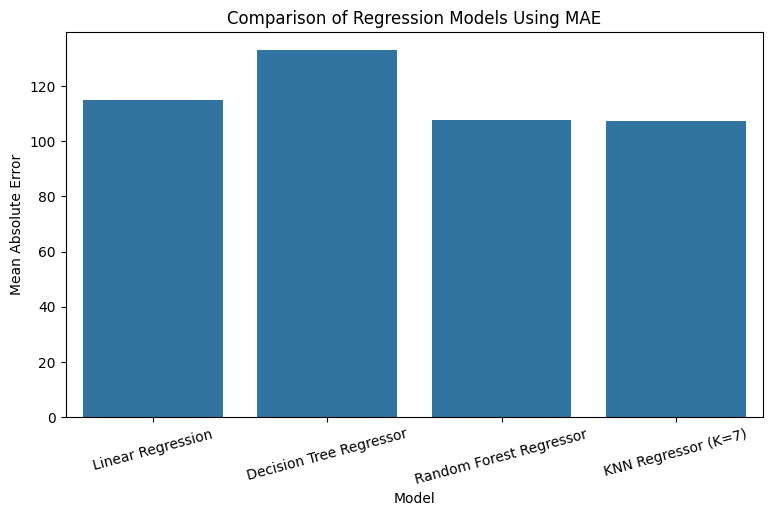

In [68]:
plt.figure(figsize=(9, 5))
sns.barplot(data=regression_results, x='Model', y='MAE')

plt.title('Comparison of Regression Models Using MAE')
plt.xlabel('Model')
plt.ylabel('Mean Absolute Error')
plt.xticks(rotation=15)

plt.show()

## 12. Model Comparison

The regression models are compared using MAE, MSE, and R² score.

Lower MAE and MSE values indicate lower prediction error, while a higher R² score generally indicates better regression performance.

Logistic Regression is evaluated separately because it was used for a binary classification task rather than predicting the exact bike rental count.


# Final Conclusion

This project applied multiple machine learning approaches to the Bike Sharing Demand dataset.

For the regression task, four models were compared: Linear Regression, Decision Tree Regressor, Random Forest Regressor, and K-Nearest Neighbors Regressor.

Among these models, **K-Nearest Neighbors with K = 7** achieved the best overall performance based on the results obtained in this project, with the highest R² score of approximately **0.332** and the lowest MSE among the tested regression models.

Random Forest also performed well and was the second-best regression model based on the obtained metrics.

The Decision Tree Regressor performed the worst among the regression models, with a negative R² score on the testing data.

Logistic Regression was used separately for a binary classification task that divided bike demand into lower-demand and higher-demand categories. It achieved an accuracy of approximately **72.91%**.

Overall, based on the regression metrics obtained in this project, **KNN with K = 7 would be selected as the best model among the models tested**. However, the relatively modest R² scores suggest that additional feature engineering, especially extracting useful information from the `datetime` column, could potentially improve future model performance.
